# Predicción multiclase del rendimiento estudiantil con LSTM

**Computación Emergente (FPTSP25)** 

Grupo 1E: Carrillo, Nelson - Lovera, Luis Mariano - Pérez, Luis

Clasificador LSTM que predice el resultado final de los estudiantes del *Open University
Learning Analytics Dataset* (OULAD) en cuatro categorías: *Distinction*, *Pass*, *Fail* y *Withdrawn*.

## Importaciones

El proyecto utiliza las librerías listadas a continuación a lo largo de sus fases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input  
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

2026-06-18 00:13:34.407560: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781741614.664752      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781741614.728591      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781741615.329080      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781741615.329148      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781741615.329151      16 computation_placer.cc:177] computation placer alr

## Fase N. 1. Preparación de datos
### 1.1. Carga del dataset

Dos tablas del OULAD constituyen la base del análisis: `studentInfo` (variables
demográficas, académicas y la variable objetivo) y `studentVle` (registros de interacción
con el entorno virtual de aprendizaje).

In [2]:
def cargar_datos(ruta):
    """Cargar las tablas studentInfo y studentVle desde la ruta indicada.

    Parameters
    ----------
    ruta : str
        Carpeta que contiene los archivos CSV del dataset.

    Returns
    -------
    tuple of pandas.DataFrame
        Las tablas student_info y student_vle.
    """
    student_info = pd.read_csv(ruta + "studentInfo.csv")
    student_vle = pd.read_csv(ruta + "studentVle.csv")
    return student_info, student_vle

In [3]:
# Ruta del dataset en Kaggle y carga de las tablas
ruta = "/kaggle/input/datasets/anlgrbz/student-demographics-online-education-dataoulad/"
student_info, student_vle = cargar_datos(ruta)

print("studentInfo:", student_info.shape, "| studentVle:", student_vle.shape)

studentInfo: (32593, 12) | studentVle: (10655280, 6)


### 1.2. Limpieza y selección de variables (studentInfo)

Este paso conserva las variables predictoras y la variable objetivo definidas en el
anteproyecto. Cada
registro representa una inscripción única (estudiante–módulo–presentación).

In [4]:
def limpiar_studentinfo(student_info, columnas):
    """Seleccionar las variables declaradas y descartar filas sin variable objetivo.

    Parameters
    ----------
    student_info : pandas.DataFrame
        Tabla original de estudiantes.
    columnas : list of str
        Columnas a conservar (claves, predictoras y objetivo).

    Returns
    -------
    pandas.DataFrame
        Tabla reducida a las columnas indicadas.
    """
    datos = student_info[columnas].copy()
    datos = datos.dropna(subset=["final_result"])
    return datos

In [5]:
columnas_a_usar = ["id_student", "code_module", "code_presentation",
                   "gender", "region", "age_band", "highest_education", "disability",
                   "imd_band", "studied_credits", "num_of_prev_attempts", "final_result"]
claves = ["id_student", "code_module", "code_presentation"]

datos = limpiar_studentinfo(student_info, columnas_a_usar)
datos["imd_band"] = datos["imd_band"].fillna("Desconocido") # faltantes como categoría propia
print("Nulos en final_result:", student_info["final_result"].isna().sum())
print("Registros:", len(datos), "| Inscripciones únicas:", len(datos[claves].drop_duplicates()))
print("Dimensiones:", datos.shape)

Nulos en final_result: 0
Registros: 32593 | Inscripciones únicas: 32593
Dimensiones: (32593, 12)


### 1.3. Codificación de variables categóricas

Las redes neuronales operan sobre valores numéricos, por lo que las variables
categóricas se transforman mediante *label encoding*. Esta es una técnica donde a cada categoría se le asigna un número entero. Por lo tanto, se codifican las seis variables declaradas.

In [6]:
def codificar_categoricas(datos, columnas_categoricas):
    """Convertir las variables categóricas en números mediante label encoding.

    Parameters
    ----------
    datos : pandas.DataFrame
        Tabla con las variables a transformar.
    columnas_categoricas : list of str
        Nombres de las columnas categóricas a codificar.

    Returns
    -------
    pandas.DataFrame
        La misma tabla con las variables categóricas codificadas.
    """
    datos = datos.copy()
    codificador = LabelEncoder()
    for columna in columnas_categoricas:
        # Asignación de un número entero a cada categoría
        datos[columna] = codificador.fit_transform(datos[columna])
    return datos

In [7]:
# Variables categóricas a codificar y aplicación de la función
columnas_categoricas = ["gender", "region", "age_band", "highest_education", "disability", "imd_band"]
datos = codificar_categoricas(datos, columnas_categoricas)

datos.head()

,id_student,code_module,code_presentation,gender,region,age_band,highest_education,disability,imd_band,studied_credits,num_of_prev_attempts,final_result
0,11391,AAA,2013J,1,0,2,1,0,9,240,0,Pass
1,28400,AAA,2013J,0,6,1,1,0,2,60,0,Pass
2,30268,AAA,2013J,0,5,1,0,1,3,60,0,Withdrawn
3,31604,AAA,2013J,0,7,1,0,0,5,60,0,Pass
4,32885,AAA,2013J,0,11,0,2,0,5,60,0,Pass


## Fase N. 2. Modelado
### 2.1. Construcción de secuencias temporales semanales

A partir de los registros diarios de interacción (`studentVle`), se construyen secuencias
semanales que representan la evolución de la actividad de cada estudiante durante el curso.
Los clics diarios se agregan en totales por semana, siguiendo el enfoque de Kaushal y Mall (2025).

In [8]:
def agregar_clics(student_vle, claves):
    """Agregar los clics diarios en totales por inscripción y semana.

    Parameters
    ----------
    student_vle : pandas.DataFrame
        Registros diarios de interacción con el entorno virtual.
    claves : list of str
        Columnas que identifican una inscripción única.

    Returns
    -------
    pandas.DataFrame
        Clics totales por inscripción y semana del curso.
    """
    # Descarte de la actividad previa al inicio del curso (date negativo)
    vle = student_vle[student_vle["date"] >= 0].copy()

    # Cálculo de la semana del curso a partir del día
    vle["semana"] = vle["date"] // 7

    # Recorte a las semanas hasta el último hito considerado (semana 20)
    vle = vle[vle["semana"] <= 20]

    # Suma de clics por inscripción y semana
    clics_semana = vle.groupby(claves + ["semana"])["sum_click"].sum().reset_index()
    return clics_semana

In [9]:
# Construcción de las secuencias semanales de clics
clics_semana = agregar_clics(student_vle, claves)
clics_semana.head()

,id_student,code_module,code_presentation,semana,sum_click
0,6516,AAA,2014J,0,229
1,6516,AAA,2014J,1,42
2,6516,AAA,2014J,2,79
3,6516,AAA,2014J,3,193
4,6516,AAA,2014J,4,69


Una vez agregados los clics por semana, se reorganiza la tabla a formato matricial: cada
inscripción ocupa una sola fila y cada semana una columna, con su total de clics. Esta
matriz constituye la secuencia temporal que recibirá la red. Las semanas sin actividad se
completan con cero.

In [10]:
def construir_secuencias(clics_semana, claves):
    """Reorganizar los clics semanales en una matriz por inscripción.

    Cada fila representa una inscripción y cada columna una semana del curso, con el total
    de clics correspondiente. Las semanas sin actividad se completan con cero.

    Parameters
    ----------
    clics_semana : pandas.DataFrame
        Clics totales por inscripción y semana, en formato largo.
    claves : list of str
        Columnas que identifican una inscripción única.

    Returns
    -------
    pandas.DataFrame
        Una fila por inscripción con una columna por semana.
    """
    secuencias = clics_semana.pivot_table(
        index=claves,
        columns="semana",
        values="sum_click",
        fill_value=0,
    ).reset_index()
    return secuencias

In [11]:
# Reorganización de los clics semanales en la matriz de secuencias
secuencias = construir_secuencias(clics_semana, claves)

print("Dimensiones de las secuencias:", secuencias.shape)
secuencias.head()

Dimensiones de las secuencias: (28482, 24)


semana,id_student,code_module,code_presentation,0,1,2,3,4,5,6,...,11,12,13,14,15,16,17,18,19,20
0,6516,AAA,2014J,229.0,42.0,79.0,193.0,69.0,34.0,10.0,...,46.0,2.0,3.0,18.0,33.0,76.0,17.0,151.0,111.0,38.0
1,8462,DDD,2013J,81.0,146.0,9.0,23.0,79.0,18.0,63.0,...,5.0,52.0,17.0,1.0,9.0,12.0,0.0,0.0,0.0,0.0
2,8462,DDD,2014J,0.0,10.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,11391,AAA,2013J,183.0,20.0,100.0,0.0,26.0,60.0,22.0,...,31.0,2.0,5.0,27.0,9.0,0.0,27.0,55.0,0.0,0.0
4,23629,BBB,2013B,23.0,5.0,9.0,2.0,0.0,8.0,0.0,...,0.0,30.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### 2.2. Integración de variables estáticas y secuencias

Este paso combina las variables estáticas (demográficas y académicas) con las secuencias
semanales, enlazando ambas tablas por la inscripción. Las inscripciones sin actividad
registrada conservan su información estática y reciben una secuencia de ceros, de modo que
ningún estudiante queda excluido del análisis.

In [12]:
def combinar_tablas(datos, secuencias, claves):
    """Combinar las variables estáticas con las secuencias semanales por inscripción.

    Las inscripciones sin actividad conservan sus variables estáticas y reciben una
    secuencia de ceros.

    Parameters
    ----------
    datos : pandas.DataFrame
        Variables estáticas y variable objetivo por inscripción.
    secuencias : pandas.DataFrame
        Secuencias semanales de clics por inscripción.
    claves : list of str
        Columnas que identifican una inscripción única.

    Returns
    -------
    pandas.DataFrame
        Conjunto con variables estáticas y secuencia por inscripción.
    """
    completo = datos.merge(secuencias, on=claves, how="left")
    # Relleno con cero de las semanas sin actividad
    completo = completo.fillna(0)
    return completo

In [13]:
# Unión de las variables estáticas con las secuencias semanales
completo = combinar_tablas(datos, secuencias, claves)

print("Dimensiones del conjunto completo:", completo.shape)
print("Valores nulos restantes:", completo.isna().sum().sum())
completo.head()

Dimensiones del conjunto completo: (32593, 33)
Valores nulos restantes: 0


,id_student,code_module,code_presentation,gender,region,age_band,highest_education,disability,imd_band,studied_credits,...,11,12,13,14,15,16,17,18,19,20
0,11391,AAA,2013J,1,0,2,1,0,9,240,...,31.0,2.0,5.0,27.0,9.0,0.0,27.0,55.0,0.0,0.0
1,28400,AAA,2013J,0,6,1,1,0,2,60,...,10.0,59.0,39.0,14.0,22.0,0.0,28.0,24.0,39.0,4.0
2,30268,AAA,2013J,0,5,1,0,1,3,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,31604,AAA,2013J,0,7,1,0,0,5,60,...,0.0,39.0,65.0,99.0,45.0,56.0,38.0,87.0,36.0,21.0
4,32885,AAA,2013J,0,11,0,2,0,5,60,...,50.0,8.0,38.0,0.0,25.0,0.0,31.0,18.0,26.0,3.0


### 2.3. Codificación de la variable objetivo

La variable `final_result` contiene las cuatro categorías de rendimiento en texto. Cada
categoría se transforma en una columna binaria (formato *one-hot*), que es lo que requiere
la capa de salida *softmax* del modelo: una probabilidad por cada clase.


In [14]:
def codificar_target(completo):
    """Codificar la variable objetivo en formato one-hot.

    Cada categoría de `final_result` se convierte en una columna binaria, formato que
    requiere la capa de salida softmax (una probabilidad por clase).

    Parameters
    ----------
    completo : pandas.DataFrame
        Conjunto que contiene la columna `final_result`.

    Returns
    -------
    pandas.DataFrame
        Variable objetivo en formato one-hot, una columna por clase.
    """
    objetivo = pd.get_dummies(completo["final_result"]).astype(int)
    return objetivo

In [15]:
# Codificación de la variable objetivo en formato one-hot
objetivo = codificar_target(completo)

print("Dimensiones del objetivo:", objetivo.shape)
objetivo.head()

Dimensiones del objetivo: (32593, 4)


,Distinction,Fail,Pass,Withdrawn
0,0,0,1,0
1,0,0,1,0
2,0,0,0,1
3,0,0,1,0
4,0,0,1,0


### 2.4. Construcción del tensor de entrada 3D

Las redes LSTM requieren la entrada con forma `(muestras, pasos_de_tiempo,
características)`. En este paso se reorganiza el conjunto `completo` en un tensor
tridimensional donde cada paso temporal corresponde a una semana del curso. Las
variables estáticas (demográficas, académicas y de preinscripción) se replican en
cada paso, mientras que los clics semanales aportan la dimensión temporal,
siguiendo la representación empleada por Kaushal y Mall (2025).

In [16]:
def construir_tensor_3d(completo, claves, variables_estaticas, objetivo="final_result"):
    """Construir el tensor 3D que recibe la red LSTM.

    Cada inscripción se representa como una secuencia de semanas. En cada paso
    temporal se concatenan las variables estáticas (replicadas) y el número de
    clics correspondiente a esa semana.

    Parameters
    ----------
    completo : pandas.DataFrame
        Tabla con variables estáticas y columnas semanales.
    claves : list of str
        Columnas que identifican una inscripción única.
    variables_estaticas : list of str
        Variables que se replican en cada paso temporal.
    objetivo : str
        Nombre de la columna objetivo, excluida del tensor.

    Returns
    -------
    numpy.ndarray
        Tensor de forma (n_inscripciones, n_semanas, n_caracteristicas).
    """
    # Identificación de las columnas semanales por exclusión
    excluir = set(claves + variables_estaticas + [objetivo])
    columnas_semana = sorted([c for c in completo.columns if c not in excluir],
                             key=lambda c: int(c))

    n_inscripciones = len(completo)
    n_semanas = len(columnas_semana)
    n_caracteristicas = len(variables_estaticas) + 1

    tensor = np.zeros((n_inscripciones, n_semanas, n_caracteristicas), dtype=np.float32)

    # Replicación de las variables estáticas en cada paso temporal
    estaticas = completo[variables_estaticas].to_numpy(dtype=np.float32)
    tensor[:, :, :len(variables_estaticas)] = estaticas[:, np.newaxis, :]

    # Clics semanales en la última posición de cada paso
    clics = completo[columnas_semana].to_numpy(dtype=np.float32)
    tensor[:, :, -1] = clics

    return tensor

In [17]:
# Construcción del tensor 3D que alimenta la red LSTM
variables_estaticas = ["gender", "region", "age_band", "highest_education", "imd_band", 
                       "disability", "studied_credits", "num_of_prev_attempts"]

X = construir_tensor_3d(completo, claves, variables_estaticas)
y = objetivo.to_numpy(dtype=np.float32)

print("Forma del tensor de entrada X:", X.shape)
print("Forma del tensor objetivo y:", y.shape)

Forma del tensor de entrada X: (32593, 21, 9)
Forma del tensor objetivo y: (32593, 4)


### 2.5. Arquitectura de la red LSTM

La arquitectura sigue las especificaciones del anteproyecto: dos capas LSTM de
64 unidades, una capa de *dropout* del 30% tras cada una para reducir el
sobreajuste, y una capa densa de salida con activación *softmax* que produce la
probabilidad de pertenencia a cada una de las cuatro categorías. El modelo se
compila con el optimizador Adam con una tasa de aprendizaje de 0,001 y la
función de pérdida *categorical cross-entropy*, adecuada para clasificación
multiclase.

In [18]:
def construir_modelo_lstm(forma_entrada, n_clases=4, tasa_aprendizaje=0.001):
    """Construir y compilar la arquitectura LSTM definida en el anteproyecto.

    Dos capas LSTM con 64 unidades cada una, dropout del 30% tras cada capa, y
    capa densa final con activación softmax para clasificación multiclase.

    Parameters
    ----------
    forma_entrada : tuple of int
        Forma de cada secuencia (pasos_tiempo, características).
    n_clases : int
        Número de categorías de la variable objetivo.
    tasa_aprendizaje : float
        Tasa de aprendizaje usada por el optimizador Adam.

    Returns
    -------
    tensorflow.keras.Model
        Modelo compilado listo para entrenamiento.
    """
    modelo = Sequential([
        Input(shape=forma_entrada),
        LSTM(64, return_sequences=True),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(n_clases, activation="softmax"),
    ])
    modelo.compile(
        optimizer=Adam(learning_rate=tasa_aprendizaje),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return modelo

In [19]:
# Instanciación del modelo a partir de la forma del tensor de entrada
forma_entrada = (X.shape[1], X.shape[2])
modelo = construir_modelo_lstm(forma_entrada, n_clases=y.shape[1])

modelo.summary()

2026-06-18 00:13:59.535339: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 21, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,228 (204.02 KB)

 Trainable params: 52,228 (204.02 KB)

 Non-trainable params: 0 (0.00 B)

## Fase N. 3. Evaluación
### 3.1. División temporal del conjunto

Para reproducir el protocolo de evaluación empleado por Karimi et al. (2020), las
inscripciones se separan según el año de la presentación del curso. Las
presentaciones de 2013 conforman el conjunto de entrenamiento, mientras que las
de 2014 se reservan para validación y prueba. Esta partición garantiza que el
modelo se evalúe sobre presentaciones que no ha visto durante el entrenamiento,
respetando el orden temporal real de los datos.

In [20]:
def dividir_temporal(X, y, completo, anio_entrenamiento="2013", anio_prueba="2014"):
    """Separar el conjunto en entrenamiento y prueba según el año de la presentación.

    Las inscripciones cuyo `code_presentation` empieza por el año de entrenamiento
    forman el conjunto de entrenamiento; las del año de prueba forman el conjunto
    de prueba.

    Parameters
    ----------
    X : numpy.ndarray
        Tensor 3D de entrada.
    y : numpy.ndarray
        Tensor objetivo en formato one-hot.
    completo : pandas.DataFrame
        Tabla con la columna `code_presentation` para identificar el año.
    anio_entrenamiento : str
        Prefijo de las presentaciones de entrenamiento.
    anio_prueba : str
        Prefijo de las presentaciones de prueba.

    Returns
    -------
    tuple of numpy.ndarray
        X_entrenamiento, X_prueba, y_entrenamiento, y_prueba.
    """
    presentacion = completo["code_presentation"].astype(str)

    mascara_entrenamiento = presentacion.str.startswith(anio_entrenamiento).to_numpy()
    mascara_prueba = presentacion.str.startswith(anio_prueba).to_numpy()

    X_entrenamiento = X[mascara_entrenamiento]
    X_prueba = X[mascara_prueba]
    y_entrenamiento = y[mascara_entrenamiento]
    y_prueba = y[mascara_prueba]

    return X_entrenamiento, X_prueba, y_entrenamiento, y_prueba

In [21]:
# Aplicación de la división temporal
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = dividir_temporal(X, y, completo)

print("Entrenamiento (2013):", X_entrenamiento.shape, y_entrenamiento.shape)
print("Prueba (2014):       ", X_prueba.shape, y_prueba.shape)

Entrenamiento (2013): (13529, 21, 9) (13529, 4)
Prueba (2014):        (19064, 21, 9) (19064, 4)


**3.2. Escalado de características**

Las características presentan escalas muy distintas: los clics semanales alcanzan
valores de varios miles, los créditos cursados llegan a centenas y las variables
categóricas codificadas se mueven entre cero y unas pocas decenas. Sin un escalado
previo, las características de mayor magnitud dominarían el ajuste de la red y
dificultarían la convergencia. Por ello, las características se estandarizan a media
cero y desviación unitaria. El escalador se ajusta únicamente con las inscripciones
de entrenamiento (2013) y luego transforma ambos conjuntos, de modo que ninguna
información del conjunto de prueba (2014) interviene en el ajuste.

In [22]:
def escalar_caracteristicas(X_entrenamiento, X_prueba):
    """Estandarizar el tensor 3D ajustando el escalador solo con entrenamiento.

    El tensor se aplana a dos dimensiones para ajustar un único escalador por
    característica; luego se restaura su forma tridimensional original. El ajuste
    se realiza exclusivamente sobre el conjunto de entrenamiento para evitar la
    filtración de información del conjunto de prueba. Adicionalmente, se retorna
    el escalador ajustado para que pueda reutilizarse en operaciones posteriores
    (por ejemplo, calcular el valor escalado equivalente a cero clics reales).

    Parameters
    ----------
    X_entrenamiento : numpy.ndarray
        Tensor 3D de entrenamiento, forma (inscripciones, semanas, características).
    X_prueba : numpy.ndarray
        Tensor 3D de prueba con la misma estructura.

    Returns
    -------
    tuple
        (X_entrenamiento escalado, X_prueba escalado, escalador ajustado).
    """
    n_semanas = X_entrenamiento.shape[1]
    n_caracteristicas = X_entrenamiento.shape[2]

    escalador = StandardScaler()

    # Ajuste y transformación del entrenamiento (aplanado a 2D)
    entrenamiento_2d = X_entrenamiento.reshape(-1, n_caracteristicas)
    entrenamiento_2d = escalador.fit_transform(entrenamiento_2d)

    # Transformación de la prueba con los parámetros del entrenamiento
    prueba_2d = X_prueba.reshape(-1, n_caracteristicas)
    prueba_2d = escalador.transform(prueba_2d)

    # Restauración de la forma tridimensional
    X_entrenamiento_esc = entrenamiento_2d.reshape(-1, n_semanas, n_caracteristicas)
    X_prueba_esc = prueba_2d.reshape(-1, n_semanas, n_caracteristicas)

    return X_entrenamiento_esc, X_prueba_esc, escalador

In [23]:
# Escalado de las características ajustando solo con el conjunto de entrenamiento.
X_entrenamiento, X_prueba, escalador = escalar_caracteristicas(X_entrenamiento, X_prueba)

print("Media tras escalar (entrenamiento):", X_entrenamiento.mean().round(3))
print("Desv. estándar (entrenamiento):    ", X_entrenamiento.std().round(3))

Media tras escalar (entrenamiento): 0.0
Desv. estándar (entrenamiento):     1.0


**3.3. Entrenamiento del modelo**

El modelo se entrena con las inscripciones de 2013 utilizando los hiperparámetros
declarados en el anteproyecto: optimizador Adam con tasa de aprendizaje 0,001 y
función de pérdida *categorical cross-entropy*. Una fracción del conjunto de
entrenamiento se reserva como validación interna durante el ajuste, lo que
permite monitorear el desempeño en datos no vistos en cada época.

In [24]:
def entrenar_modelo(modelo, X_entrenamiento, y_entrenamiento, epocas=20, lote=128, validacion=0.1):
    """Entrenar el modelo LSTM sobre el conjunto de entrenamiento.

    Parameters
    ----------
    modelo : tensorflow.keras.Model
        Modelo compilado previamente.
    X_entrenamiento : numpy.ndarray
        Tensor de entrada para entrenamiento.
    y_entrenamiento : numpy.ndarray
        Tensor objetivo para entrenamiento.
    epocas : int
        Número de épocas de entrenamiento.
    lote : int
        Tamaño del lote (batch).
    validacion : float
        Fracción del conjunto de entrenamiento reservada para validación interna.

    Returns
    -------
    tensorflow.keras.callbacks.History
        Historial con las métricas registradas en cada época.
    """
    historial = modelo.fit(
        X_entrenamiento,
        y_entrenamiento,
        epochs=epocas,
        batch_size=lote,
        validation_split=validacion,
        verbose=1,
    )
    return historial

In [25]:
# Entrenamiento del modelo con las inscripciones de 2013
historial = entrenar_modelo(modelo, X_entrenamiento, y_entrenamiento)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 0.5149 - loss: 1.1112 - val_accuracy: 0.3489 - val_loss: 1.5227
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5810 - loss: 0.9907 - val_accuracy: 0.4730 - val_loss: 1.2231
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.5984 - loss: 0.9511 - val_accuracy: 0.5004 - val_loss: 1.1476
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6140 - loss: 0.9198 - val_accuracy: 0.5351 - val_loss: 1.0899
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.6231 - loss: 0.9047 - val_accuracy: 0.5750 - val_loss: 1.0205
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6240 - loss: 0.8995 - val_accuracy: 0.5721 - val_loss: 1.0538
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.6296 - loss: 0.8903 - val_accuracy: 0.5580 - val_loss: 1.0236
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6307 - loss: 0.8887 - val_accuracy: 0.5536 - v

**3.4. Exploración de configuraciones**

El entrenamiento anterior emplea los hiperparámetros declarados en el
anteproyecto. Para verificar que dicha configuración es adecuada, se exploran
varias alternativas que varían la tasa de aprendizaje, el tamaño de lote, el
número de épocas y la aplicación de pesos por clase. Estos últimos compensan el
desbalance entre las cuatro categorías, otorgando mayor peso a las clases
minoritarias durante el ajuste.

Cada configuración se entrena sobre una partición del conjunto de 2013 y se
evalúa sobre una validación interna reservada de ese mismo año, de modo que el
conjunto de prueba de 2014 permanece intacto hasta el análisis final. La
configuración con mejor F1-score macro se selecciona y se reentrena sobre la
totalidad de 2013.

In [26]:
def calcular_pesos_clase(y):
    """Calcular pesos inversamente proporcionales a la frecuencia de cada clase.

    Parameters
    ----------
    y : numpy.ndarray
        Etiquetas en formato one-hot.

    Returns
    -------
    dict
        Diccionario {indice_clase: peso} para el parámetro class_weight de Keras.
    """
    conteos = y.sum(axis=0)
    total = conteos.sum()
    n_clases = len(conteos)
    pesos = total / (n_clases * conteos)
    return {i: float(p) for i, p in enumerate(pesos)}

In [27]:
def explorar_configuraciones(configuraciones, X_entrenamiento, y_entrenamiento,
                             forma_entrada, n_clases, fraccion_validacion=0.1, semilla=42):
    """Entrenar y comparar varias configuraciones sobre una validación interna.

    Para cada configuración se construye un modelo nuevo, se entrena sobre una
    partición de 2013 y se evalúa sobre la validación reservada del mismo año. El
    conjunto de prueba de 2014 no interviene en este proceso.

    Parameters
    ----------
    configuraciones : list of dict
        Lista de configuraciones a comparar.
    X_entrenamiento : numpy.ndarray
        Tensor 3D de entrenamiento (escalado).
    y_entrenamiento : numpy.ndarray
        Etiquetas de entrenamiento en formato one-hot.
    forma_entrada : tuple of int
        Forma de cada secuencia (pasos_tiempo, características).
    n_clases : int
        Número de categorías de la variable objetivo.
    fraccion_validacion : float
        Proporción de 2013 reservada como validación interna.
    semilla : int
        Semilla para reproducir la partición.

    Returns
    -------
    pandas.DataFrame
        Tabla con accuracy y F1-score macro de validación por configuración.
    """
    # Partición barajada de validación interna
    generador = np.random.default_rng(semilla)
    indices = generador.permutation(len(X_entrenamiento))
    corte = int(len(indices) * (1 - fraccion_validacion))
    idx_tr, idx_val = indices[:corte], indices[corte:]

    X_tr, X_val = X_entrenamiento[idx_tr], X_entrenamiento[idx_val]
    y_tr, y_val = y_entrenamiento[idx_tr], y_entrenamiento[idx_val]
    clases_val = np.argmax(y_val, axis=1)

    resultados = []
    for configuracion in configuraciones:
        modelo_cfg = construir_modelo_lstm(
            forma_entrada, n_clases, tasa_aprendizaje=configuracion["tasa_aprendizaje"])

        pesos = calcular_pesos_clase(y_tr) if configuracion["balanceo"] else None

        modelo_cfg.fit(
            X_tr, y_tr,
            epochs=configuracion["epocas"],
            batch_size=configuracion["lote"],
            class_weight=pesos,
            verbose=0,
        )

        clases_predichas = np.argmax(modelo_cfg.predict(X_val, verbose=0), axis=1)
        resultados.append({
            "configuracion": configuracion["nombre"],
            "accuracy_val": accuracy_score(clases_val, clases_predichas),
            "f1_macro_val": f1_score(clases_val, clases_predichas,
                                     average="macro", zero_division=0),
        })

    return pd.DataFrame(resultados)

In [28]:
# Configuraciones a comparar (arquitectura 2x64 fija; varían hiperparámetros de ajuste)
configuraciones = [
    {"nombre": "Base (anteproyecto)",    "tasa_aprendizaje": 0.001,  "lote": 128, "epocas": 20, "balanceo": False},
    {"nombre": "Base + balanceo",        "tasa_aprendizaje": 0.001,  "lote": 128, "epocas": 20, "balanceo": True},
    {"nombre": "LR menor + balanceo",    "tasa_aprendizaje": 0.0005, "lote": 128, "epocas": 30, "balanceo": True},
    {"nombre": "Lote menor + balanceo",  "tasa_aprendizaje": 0.001,  "lote": 64,  "epocas": 20, "balanceo": True},
]

tabla_configuraciones = explorar_configuraciones(
    configuraciones, X_entrenamiento, y_entrenamiento, forma_entrada, n_clases=y.shape[1])

tabla_configuraciones.round(4)

,configuracion,accuracy_val,f1_macro_val
0,Base (anteproyecto),0.6208,0.4321
1,Base + balanceo,0.4930,0.4689
2,LR menor + balanceo,0.4775,0.4545
3,Lote menor + balanceo,0.5011,0.4665


In [29]:
# Selección de la mejor configuración por F1-score macro de validación
mejor = tabla_configuraciones.sort_values("f1_macro_val", ascending=False).iloc[0]
configuracion_elegida = next(c for c in configuraciones if c["nombre"] == mejor["configuracion"])
print("Configuración seleccionada:", configuracion_elegida["nombre"])

# Reentrenamiento final con la configuración elegida sobre la totalidad de 2013.
# Se conserva validation_split=0.1 para monitorear el ajuste durante las épocas.
modelo = construir_modelo_lstm(forma_entrada, n_clases=y.shape[1],
                               tasa_aprendizaje=configuracion_elegida["tasa_aprendizaje"])
pesos_finales = calcular_pesos_clase(y_entrenamiento) if configuracion_elegida["balanceo"] else None

historial = modelo.fit(
    X_entrenamiento, y_entrenamiento,
    epochs=configuracion_elegida["epocas"],
    batch_size=configuracion_elegida["lote"],
    class_weight=pesos_finales,
    validation_split=0.1,
    verbose=1,
)

Configuración seleccionada: Base + balanceo
Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.3696 - loss: 1.1941 - val_accuracy: 0.3599 - val_loss: 1.3010
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4658 - loss: 1.0784 - val_accuracy: 0.3851 - val_loss: 1.2764
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5011 - loss: 1.0298 - val_accuracy: 0.5063 - val_loss: 1.1132
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.4946 - loss: 1.0088 - val_accuracy: 0.4782 - val_loss: 1.1975
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5182 - loss: 0.9920 - val_accuracy: 0.5174 - val_loss: 1.0560
Epoch 6/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5110 - loss: 0.9828 - val_accuracy: 0.4656 - val_loss: 1.2135
Epoch 7/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5194 - loss: 0.9725 - val_accuracy: 0.5447 - val_loss: 1.0353
Epoch 8/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.52

### 3.5. Entrenamiento snapshot-specific por hito

La evaluación por hitos definida en el anteproyecto requiere medir el desempeño
del modelo en seis momentos del curso (semanas 2, 4, 8, 12, 16 y 20). Una
alternativa metodológica al enmascaramiento consiste en entrenar un modelo
independiente para cada hito, en el que tanto el entrenamiento como la
evaluación operan con secuencias truncadas a la misma longitud. Este enfoque,
propuesto explícitamente como trabajo futuro por Kaushal y Mall (2025) bajo
la denominación de *snapshot-specific models*, evita el desajuste de
distribución que surge cuando un único modelo entrenado con secuencias
completas se evalúa sobre secuencias parcialmente enmascaradas.

Cada modelo se entrena con la misma configuración seleccionada en la sección
anterior y conserva la arquitectura LSTM definida en el anteproyecto. Las
variables estáticas se mantienen replicadas en todos los pasos temporales,
mientras que la longitud de la dimensión temporal varía según el hito.

In [30]:
def truncar_tensor_a_hito(X, hito):
    """Recortar el tensor 3D a las primeras semanas hasta el hito inclusive.

    El resultado conserva todas las inscripciones y características, pero solo
    los pasos temporales desde la semana 0 hasta la semana indicada por el hito.

    Parameters
    ----------
    X : numpy.ndarray
        Tensor 3D de forma (inscripciones, semanas, características).
    hito : int
        Última semana con información disponible (inclusive).

    Returns
    -------
    numpy.ndarray
        Tensor truncado de forma (inscripciones, hito + 1, características).
    """
    return X[:, :hito + 1, :]

In [31]:
def entrenar_modelos_por_hito(hitos, X_entrenamiento, y_entrenamiento, configuracion,
                              modelos_existentes=None):
    """Entrenar un modelo LSTM independiente para cada hito temporal.

    Cada modelo se entrena sobre secuencias truncadas a la longitud del hito
    correspondiente, utilizando los hiperparámetros de la configuración
    seleccionada en la sección anterior. Si se proporciona un diccionario de
    modelos ya entrenados, dichos hitos se omiten para evitar trabajo redundante.

    Parameters
    ----------
    hitos : list of int
        Semanas de evaluación definidas en el anteproyecto.
    X_entrenamiento : numpy.ndarray
        Tensor 3D de entrenamiento completo.
    y_entrenamiento : numpy.ndarray
        Etiquetas de entrenamiento en formato one-hot.
    configuracion : dict
        Configuración de hiperparámetros seleccionada.
    modelos_existentes : dict, opcional
        Diccionario de modelos ya entrenados por hito.

    Returns
    -------
    dict
        Diccionario {hito: modelo_entrenado}.
    """
    modelos_por_hito = dict(modelos_existentes) if modelos_existentes else {}
    pesos = calcular_pesos_clase(y_entrenamiento) if configuracion["balanceo"] else None

    for hito in hitos:
        if hito in modelos_por_hito:
            print(f"Hito {hito:2d}: ya entrenado, se omite.")
            continue

        X_ent_h = truncar_tensor_a_hito(X_entrenamiento, hito)
        forma_h = (X_ent_h.shape[1], X_ent_h.shape[2])

        modelo_h = construir_modelo_lstm(forma_h, n_clases=y_entrenamiento.shape[1],
                                          tasa_aprendizaje=configuracion["tasa_aprendizaje"])
        modelo_h.fit(
            X_ent_h, y_entrenamiento,
            epochs=configuracion["epocas"],
            batch_size=configuracion["lote"],
            class_weight=pesos,
            validation_split=0.1,
            verbose=0,
        )
        modelos_por_hito[hito] = modelo_h
        print(f"Hito {hito:2d}: modelo entrenado con secuencias de forma {X_ent_h.shape[1:]}")

    return modelos_por_hito

In [32]:
# Entrenamiento de los modelos snapshot-specific por hito.
# El modelo ya entrenado en la celda anterior corresponde al hito 20, dado que
# fue ajustado sobre secuencias completas de 21 semanas. Se reutiliza directamente
# para evitar reentrenar la misma configuración.
hitos = [2, 4, 8, 12, 16, 20]
modelos_por_hito = entrenar_modelos_por_hito(
    hitos, X_entrenamiento, y_entrenamiento,
    configuracion_elegida,
    modelos_existentes={20: modelo},
)

Hito  2: modelo entrenado con secuencias de forma (3, 9)
Hito  4: modelo entrenado con secuencias de forma (5, 9)
Hito  8: modelo entrenado con secuencias de forma (9, 9)
Hito 12: modelo entrenado con secuencias de forma (13, 9)
Hito 16: modelo entrenado con secuencias de forma (17, 9)
Hito 20: ya entrenado, se omite.


## Fase N. 4. Análisis
### 4.1. Evaluación global sobre el conjunto de prueba

La evaluación global constituye el punto de partida del análisis, ya que establece el desempeño máximo alcanzable por el modelo cuando dispone de toda la información temporal del curso. Este valor servirá como cota superior para contrastar con las evaluaciones por hito que se presentan más adelante, donde el modelo opera con información incompleta.
Las métricas seleccionadas son las declaradas en el anteproyecto: accuracy, precision, recall y F1-score. Las tres últimas se reportan en su variante macro, lo cual implica que cada una de las cuatro clases contribuye con el mismo peso al promedio final. Esta elección resulta especialmente relevante dado que el conjunto OULAD presenta un desbalance notable entre las categorías: Pass y Withdrawn concentran cerca del 70% de las inscripciones, mientras que Distinction y Fail son minoritarias. El promedio macro evita que el desempeño sobre las clases mayoritarias enmascare las dificultades del modelo en las minoritarias.

In [33]:
def calcular_metricas(y_real, y_predicho):
    """Calcular las métricas estándar de clasificación multiclase.

    Las métricas precision, recall y F1-score se calculan con promedio macro
    para tratar las cuatro clases con el mismo peso.

    Parameters
    ----------
    y_real : numpy.ndarray
        Etiquetas reales en formato one-hot.
    y_predicho : numpy.ndarray
        Probabilidades predichas por el modelo, una columna por clase.

    Returns
    -------
    dict
        Diccionario con accuracy, precision, recall y F1-score.
    """
    # Conversión de one-hot y probabilidades a índices de clase
    clases_reales = np.argmax(y_real, axis=1)
    clases_predichas = np.argmax(y_predicho, axis=1)

    metricas = {
        "accuracy": accuracy_score(clases_reales, clases_predichas),
        "precision": precision_score(clases_reales, clases_predichas, average="macro", zero_division=0),
        "recall": recall_score(clases_reales, clases_predichas, average="macro", zero_division=0),
        "f1_score": f1_score(clases_reales, clases_predichas, average="macro", zero_division=0),
    }
    return metricas

In [34]:
# Predicción sobre el conjunto de prueba con el modelo snapshot-specific de la
# semana 20, equivalente al modelo entrenado con secuencias completas.
modelo_final = modelos_por_hito[20]
X_prueba_final = truncar_tensor_a_hito(X_prueba, 20)

y_predicho = modelo_final.predict(X_prueba_final, verbose=0)
metricas_globales = calcular_metricas(y_prueba, y_predicho)

for nombre, valor in metricas_globales.items():
    print(f"{nombre:>10}: {valor:.4f}")

  accuracy: 0.5534
 precision: 0.5115
    recall: 0.5160
  f1_score: 0.5078


### 4.2. Evaluación por hito temporal

Una de las preguntas centrales del proyecto consiste en determinar en qué momento
del curso el modelo dispone de información suficiente para producir predicciones
confiables. Para responderla, se evalúa el modelo en seis hitos temporales
(semanas 2, 4, 8, 12, 16 y 20) definidos en el anteproyecto, los cuales replican
los puntos de medición empleados por Kaushal y Mall (2025).

Como el modelo se entrenó con secuencias de 21 semanas completas, evaluar en
hitos parciales requiere simular que solo se dispone de información hasta esa
semana. La estrategia adoptada consiste en enmascarar la característica temporal
(clics) de las semanas posteriores al hito, conservando las variables estáticas
en todos los pasos. Esta conservación es coherente con la realidad institucional:
atributos como el género, la edad o el nivel educativo previo están disponibles
desde el momento de la inscripción y no se modifican durante el curso.

Como los datos pasaron por un proceso de estandarización, el valor escalado que
corresponde a "cero clics reales" no es cero, sino un número negativo que se
calculó en la Fase 3 y se almacena en `cero_clics_escalado`. El enmascaramiento
utiliza ese valor para representar fielmente la ausencia de actividad en las
semanas posteriores a cada hito, de modo que las métricas reportadas reflejan
el desempeño del modelo bajo el escenario realista de "no se ha observado
actividad futura".

In [35]:
def evaluar_por_hito(modelo_hito, X_prueba_truncado, y_prueba):
    """Evaluar un modelo snapshot-specific sobre el conjunto de prueba truncado.

    A diferencia del enfoque por enmascaramiento, este protocolo evalúa cada
    modelo con secuencias de la misma longitud con la que fue entrenado, por lo
    que no requiere ningún valor de relleno. La función devuelve las métricas
    estándar definidas en el anteproyecto.

    Parameters
    ----------
    modelo_hito : tensorflow.keras.Model
        Modelo LSTM entrenado para un hito específico.
    X_prueba_truncado : numpy.ndarray
        Tensor de prueba recortado a la longitud del hito.
    y_prueba : numpy.ndarray
        Etiquetas reales en formato one-hot.

    Returns
    -------
    dict
        Métricas calculadas: accuracy, precision, recall y F1-score.
    """
    y_predicho = modelo_hito.predict(X_prueba_truncado, verbose=0)
    return calcular_metricas(y_prueba, y_predicho)

In [36]:
# Cálculo de las métricas para cada uno de los hitos temporales del anteproyecto,
# utilizando el modelo snapshot-specific correspondiente a cada hito.
resultados_por_hito = []

for hito in hitos:
    modelo_h = modelos_por_hito[hito]
    X_pru_h = truncar_tensor_a_hito(X_prueba, hito)
    metricas = evaluar_por_hito(modelo_h, X_pru_h, y_prueba)
    metricas["semana"] = hito
    resultados_por_hito.append(metricas)

tabla_hitos = pd.DataFrame(resultados_por_hito)[["semana", "accuracy", "precision", "recall", "f1_score"]]
tabla_hitos.round(4)

,semana,accuracy,precision,recall,f1_score
0,2,0.4171,0.4049,0.4231,0.3975
1,4,0.4129,0.4223,0.4359,0.3987
2,8,0.4688,0.4463,0.4592,0.4380
3,12,0.4964,0.4726,0.4869,0.4661
4,16,0.5050,0.4923,0.4904,0.4760
5,20,0.5534,0.5115,0.5160,0.5078


### 4.3. Visualización de la evolución temporal

Para facilitar la lectura del comportamiento del modelo a lo largo del curso, se
construye un gráfico de líneas que muestra la evolución de las cuatro métricas
en los hitos definidos. La representación visual permite identificar con
claridad los tramos en los que la información adicional contribuye al
desempeño y aquellos en los que el modelo se mantiene estable.

In [37]:
def graficar_evolucion_temporal(tabla_hitos):
    """Generar el gráfico de evolución de las métricas por hito temporal.

    Las cuatro métricas se representan con marcadores distintos sobre el mismo
    eje, permitiendo comparar visualmente su crecimiento a medida que el modelo
    dispone de más información del curso.

    Parameters
    ----------
    tabla_hitos : pandas.DataFrame
        Tabla con las columnas semana, accuracy, precision, recall y f1_score.

    Returns
    -------
    None
        El gráfico se muestra directamente en el notebook.
    """
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(tabla_hitos["semana"], tabla_hitos["accuracy"],
            marker="o", label="Accuracy")
    ax.plot(tabla_hitos["semana"], tabla_hitos["precision"],
            marker="d", label="Precision (macro)")
    ax.plot(tabla_hitos["semana"], tabla_hitos["recall"],
            marker="^", label="Recall (macro)")
    ax.plot(tabla_hitos["semana"], tabla_hitos["f1_score"],
            marker="s", label="F1-score (macro)")

    ax.set_xlabel("Semana del curso")
    ax.set_ylabel("Valor de la métrica")
    ax.set_title("Evolución del desempeño del modelo por hito temporal")
    ax.set_xticks(tabla_hitos["semana"])
    ax.set_ylim(0, 1)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

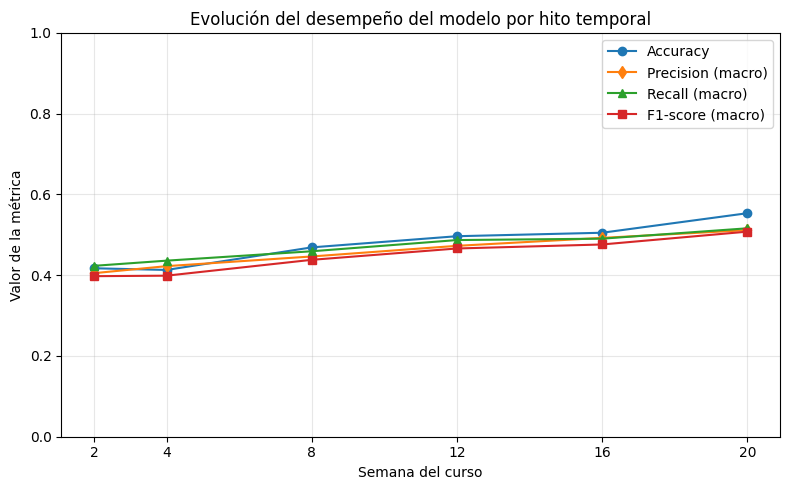

In [38]:
# Generación del gráfico de evolución temporal
graficar_evolucion_temporal(tabla_hitos)

### 4.4. Matriz de confusión

La matriz de confusión permite identificar qué categorías el modelo confunde
con mayor frecuencia. Se construye para el hito de la semana 20, que dispone de
la información temporal completa, y se etiqueta con los nombres originales de
las cuatro categorías del *Open University Learning Analytics Dataset*.

In [39]:
def construir_matriz_confusion(modelo, X_prueba, y_prueba, etiquetas):
    """Construir la matriz de confusión etiquetada con los nombres de las clases.

    Parameters
    ----------
    modelo : tensorflow.keras.Model
        Modelo LSTM entrenado.
    X_prueba : numpy.ndarray
        Tensor 3D de prueba.
    y_prueba : numpy.ndarray
        Etiquetas reales en formato one-hot.
    etiquetas : list of str
        Nombres de las clases en el orden de las columnas de y_prueba.

    Returns
    -------
    pandas.DataFrame
        Matriz de confusión con filas y columnas etiquetadas.
    """
    clases_reales = np.argmax(y_prueba, axis=1)
    clases_predichas = np.argmax(modelo.predict(X_prueba, verbose=0), axis=1)

    matriz = confusion_matrix(clases_reales, clases_predichas)
    return pd.DataFrame(matriz, index=etiquetas, columns=etiquetas)

In [40]:
# Matriz de confusión sobre el conjunto de prueba completo, utilizando el modelo
# snapshot-specific de la semana 20 (que dispone de toda la información temporal).
etiquetas_clases = list(objetivo.columns)
matriz = construir_matriz_confusion(modelo_final, X_prueba_final, y_prueba, etiquetas_clases)
matriz

,Distinction,Fail,Pass,Withdrawn
Distinction,803,121,992,32
Fail,198,1651,978,983
Pass,1781,922,4003,161
Withdrawn,140,1765,441,4093


**4.5. Tasas de verdaderos y falsos por clase**

El enunciado del proyecto requiere medir las tasas de verdaderos positivos,
verdaderos negativos, falsos positivos y falsos negativos. En una tarea
multiclase, estas cantidades se obtienen con un esquema uno-contra-resto: para
cada categoría se considera dicha clase como el caso positivo y las tres
restantes, en conjunto, como el caso negativo. A partir de la matriz de
confusión se derivan así los cuatro conteos por clase y sus tasas asociadas:
la tasa de verdaderos positivos (sensibilidad o *recall*), la tasa de
verdaderos negativos (especificidad), la tasa de falsos positivos y la tasa de
falsos negativos.

In [41]:
def calcular_tasas_por_clase(matriz):
    """Derivar VP, VN, FP, FN y sus tasas por clase desde la matriz de confusión.

    Para cada clase se aplica un esquema uno-contra-resto: la clase es el caso
    positivo y las restantes, el negativo. Los conteos se obtienen de la matriz
    de confusión y las tasas se calculan a partir de ellos.

    Parameters
    ----------
    matriz : pandas.DataFrame
        Matriz de confusión etiquetada (filas reales, columnas predichas).

    Returns
    -------
    pandas.DataFrame
        Conteos (VP, VN, FP, FN) y tasas (TVP, TVN, TFP, TFN) por clase.
    """
    m = matriz.to_numpy()
    total = m.sum()

    filas = []
    for i, clase in enumerate(matriz.index):
        VP = m[i, i]
        FN = m[i, :].sum() - VP          # reales de la clase predichos como otra
        FP = m[:, i].sum() - VP          # otras clases predichas como esta
        VN = total - VP - FP - FN        # el resto

        filas.append({
            "clase": clase,
            "VP": int(VP), "VN": int(VN), "FP": int(FP), "FN": int(FN),
            "TVP_sensibilidad": VP / (VP + FN) if (VP + FN) else 0.0,
            "TVN_especificidad": VN / (VN + FP) if (VN + FP) else 0.0,
            "TFP": FP / (FP + VN) if (FP + VN) else 0.0,
            "TFN": FN / (FN + VP) if (FN + VP) else 0.0,
        })

    return pd.DataFrame(filas)

In [42]:
# Cálculo de las tasas de verdaderos y falsos por clase
tabla_tasas = calcular_tasas_por_clase(matriz)
tabla_tasas.round(4)

,clase,VP,VN,FP,FN,TVP_sensibilidad,TVN_especificidad,TFP,TFN
0,Distinction,803,14997,2119,1145,0.4122,0.8762,0.1238,0.5878
1,Fail,1651,12446,2808,2159,0.4333,0.8159,0.1841,0.5667
2,Pass,4003,9786,2411,2864,0.5829,0.8023,0.1977,0.4171
3,Withdrawn,4093,11449,1176,2346,0.6357,0.9069,0.0931,0.3643
